In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#해당 파일 읽어오기
train = pd.read_csv("C:/Users/User/Downloads/titanic/train.csv")
train.head()

In [17]:
train = pd.read_csv('C:/Users/User/Desktop/python/titanic/train.csv')
print(train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


### 데이터가 신뢰할만한지 확인하기
-결측치 확인하기

-이상치 확인하기

-우리가 처리하기 어려운 데이터가 있는지 확인하기

In [18]:
print(train)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [19]:
train.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


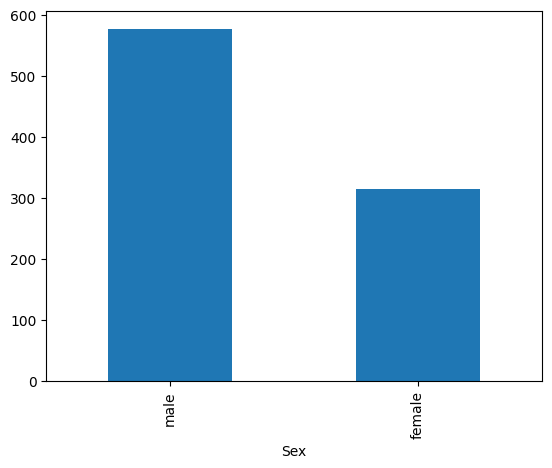

In [20]:
#명목형 데이터
train["Sex"].value_counts().plot(kind='bar')
plt.show()


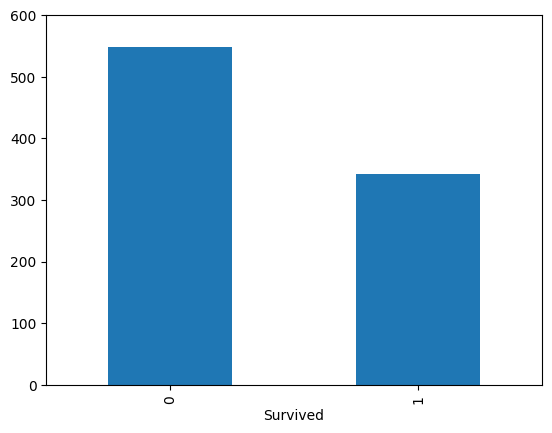

In [21]:
train["Survived"].value_counts().plot(kind='bar')
plt.ylim(0,600)
plt.show()



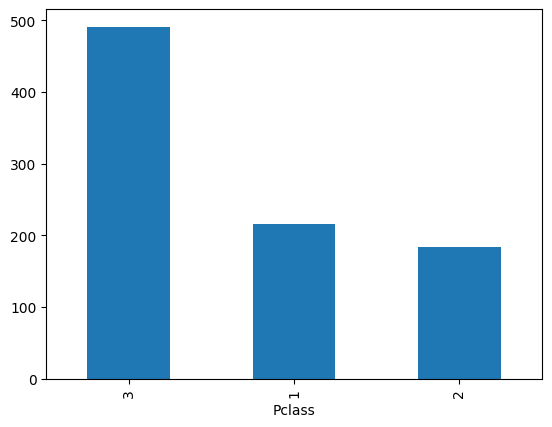

In [22]:
train["Pclass"].value_counts().plot(kind='bar')
plt.show()

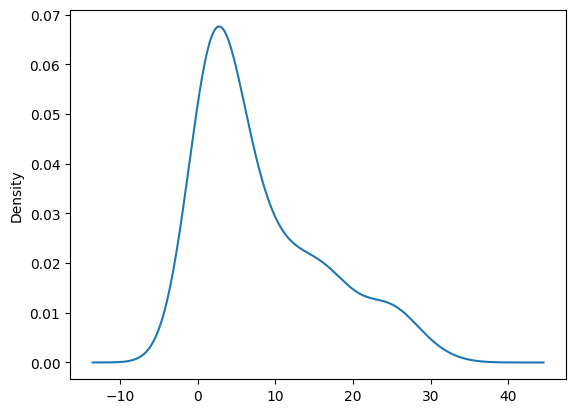

In [23]:
train["Age"].value_counts().plot(kind='kde')
plt.show()

<Axes: xlabel='Embarked'>

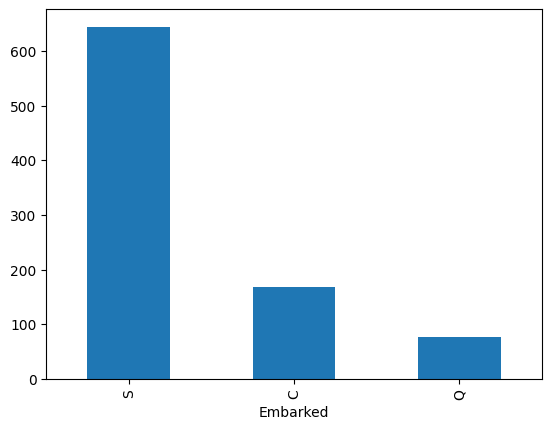

In [24]:
train["Embarked"].value_counts().plot(kind='bar')

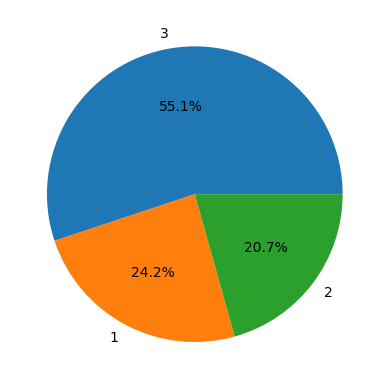

In [25]:
temp = train["Pclass"].value_counts()
plt.pie(temp.values, labels=temp.index, autopct='%.1f%%')
plt.show()

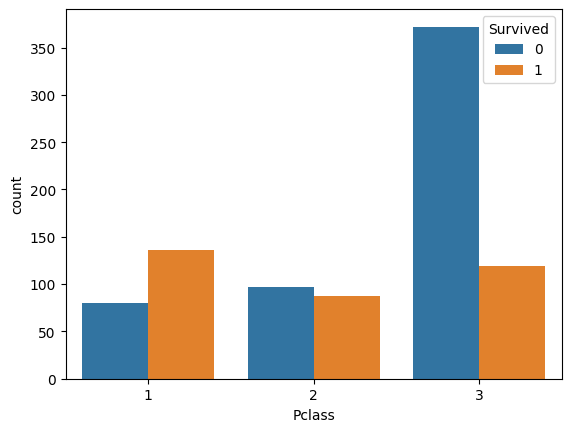

In [26]:
sns.countplot(data=train, x='Pclass', hue='Survived')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19488\2249537328.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x ="Sex", y="Survived", data=train, palette='coolwarm')


<Axes: xlabel='Sex', ylabel='Survived'>

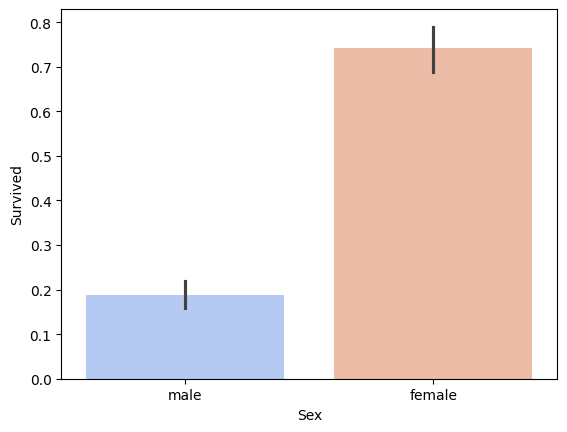

In [27]:
sns.barplot(x ="Sex", y="Survived", data=train, palette='coolwarm')

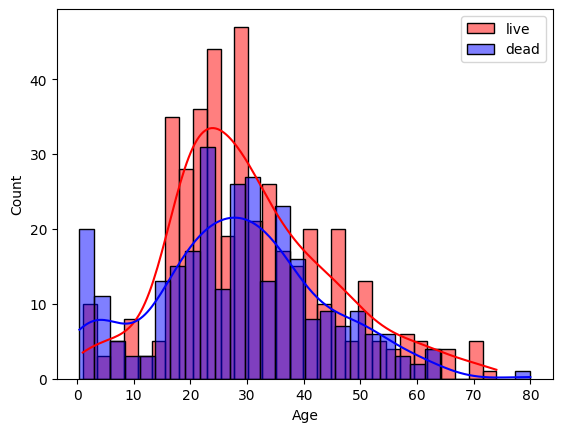

In [28]:
sns.histplot(train[train['Survived']==0]['Age'],bins=30, color='red', kde=True, label='live')
sns.histplot(train[train['Survived']==1]['Age'],bins=30, color='blue', kde=True, label='dead')
plt.legend()
plt.show()

In [29]:
pd.crosstab(train['Sex'], train['Survived'], normalize='index') * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [30]:
train.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [31]:
train.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

In [32]:
from scipy.stats import chi2_contingency

In [33]:
table = pd.crosstab(train['Pclass'], train['Survived'])
stat,pvalue, dof, excepted = chi2_contingency(table)
pvalue

np.float64(4.549251711298793e-23)

In [34]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [35]:
train[train['Embarked'].isnull()].fillna("S", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_19488\135337688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[train['Embarked'].isnull()].fillna("S", inplace=True)


In [36]:
train[train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [37]:
train[train['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [38]:
train["title"] = train['Name'].str.extract(r",\s*([^\.]+)\.")
train['title'].value_counts()

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [39]:
train[train['Age'].isnull()]['title'].value_counts()

title
Mr        119
Miss       36
Mrs        17
Master      4
Dr          1
Name: count, dtype: int64

In [40]:
print(train[train['title']=='Mr']['Age'].mean())
print(train[train['title']=='Miss']['Age'].mean())
print(train[train['title']=='Mrs']['Age'].mean())   
print(train[train['title']=='Master']['Age'].mean())


32.368090452261306
21.773972602739725
35.898148148148145
4.574166666666667


In [41]:
temp = train[train['Age'].isnull()]['title'].value_counts()
print(temp.index)

for title in temp.index:
    value = train[train['title']==title]['Age'].mean()
    print(f"{title}: {value:.2f}" )

Index(['Mr', 'Miss', 'Mrs', 'Master', 'Dr'], dtype='object', name='title')
Mr: 32.37
Miss: 21.77
Mrs: 35.90
Master: 4.57
Dr: 42.00


In [42]:
for i in temp.index:
    if i == 'Mr':
        train['Age'].fillna(train[train['title']=='Mr']['Age'].mean(), inplace=True)
    elif i == 'Miss':
        train['Age'].fillna(train[train['title']=='Miss']['Age'].mean(), inplace=True)
    elif i == 'Mrs':
        train['Age'].fillna(train[train['title']=='Mrs']['Age'].mean(), inplace=True)
    elif i == 'Master':
        train['Age'].fillna(train[train['title']=='Master']['Age'].mean(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_19488\1413630778.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train[train['title']=='Mr']['Age'].mean(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_19488\1413630778.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [43]:
pd.crosstab(train['Sex'], train['Survived'], normalize='index') * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [44]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
title            0
dtype: int64

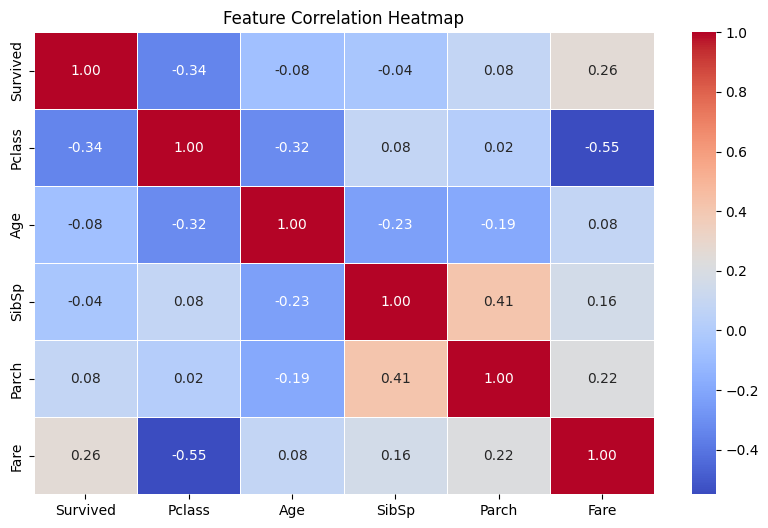

In [45]:
train_num = train[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
correlation_matrix = train_num.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [47]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'title'],
      dtype='object')

In [48]:


# df = train[["Survived","Pclass","Sex","Age","Fare"]]

# df["Age"].fillna(df["Age"].mean(), inplace=True)

train["Sex"]= LabelEncoder().fit_transform(train["Sex"])

#원핫 인코딩
train = pd.get_dummies(train, columns=["Embarked"], drop_first=True)
#train = train.map



print(train.columns)


# X = df[["Pclass", "Sex", "Age", "Fare"]]
# y = df["Survived"]

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X)
# y_train = y

# model = LogisticRegression()
# model.fit(X_train, y_train)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'title', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


In [49]:
feature = ['Pclass', 'Sex', 'Age', 'SibSp',
       'Parch',  'Fare', 'Embarked_Q', 'Embarked_S']
       # 'title_Col', 'title_Don', 'title_Dr', 'title_Jonkheer', 'title_Lady',
       # 'title_Major', 'title_Master', 'title_Miss', 'title_Mlle', 'title_Mme',
       # 'title_Mr', 'title_Mrs', 'title_Ms', 'title_Rev', 'title_Sir',
       # 'title_the Countess']


#사용할 변수
[ 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked', 'title']


X = train[feature]
y = train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# scaler = StandardScaler()
# X_train = scaler.fit_transform(X)
# y_train = y

# model = LogisticRegression()
# model.fit(X_train, y_train)

## 로지스틱 회귀

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)#모델 1000회 학습
model.fit(X_train, y_train) #실제 훈련
y_pred_log = model.predict(X_test) #예측값 기록

print(accuracy_score(y_test, y_pred_log)) #정확도
print(confusion_matrix(y_test, y_pred_log)) #혼동행렬
print(classification_report(y_test, y_pred_log, digits=3)) #정확도, 재현율, F1 점수

0.8100558659217877
[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0      0.826     0.857     0.841       105
           1      0.786     0.743     0.764        74

    accuracy                          0.810       179
   macro avg      0.806     0.800     0.803       179
weighted avg      0.809     0.810     0.809       179



In [51]:
#의사 결정 트리
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=9,random_state= 42) #모델 1000회 학습
model.fit(X_train, y_train) #실제 훈련
y_pred_log = model.predict(X_test) #예측값 기록
 
print(accuracy_score(y_test, y_pred_log)) #정확도
print(confusion_matrix(y_test, y_pred_log)) #혼동행렬
print(classification_report(y_test, y_pred_log, digits=3)) #정확도, 재현율, F1 점수


0.7988826815642458
[[93 12]
 [24 50]]
              precision    recall  f1-score   support

           0      0.795     0.886     0.838       105
           1      0.806     0.676     0.735        74

    accuracy                          0.799       179
   macro avg      0.801     0.781     0.787       179
weighted avg      0.800     0.799     0.795       179



In [52]:
#의사 결정 트리
from sklearn.tree import DecisionTreeClassifier

# 모델 생성 및 학습
model = DecisionTreeClassifier(random_state=42, max_depth=10)#모델 1000회 학습
model.fit(X_train, y_train) #실제 훈련
y_pred_log = model.predict(X_test) #예측값 기록
 
print(accuracy_score(y_test, y_pred_log)) #정확도
print(confusion_matrix(y_test, y_pred_log)) #혼동행렬
print(classification_report(y_test, y_pred_log, digits=3)) #정확도, 재현율, F1 점수


0.7988826815642458
[[93 12]
 [24 50]]
              precision    recall  f1-score   support

           0      0.795     0.886     0.838       105
           1      0.806     0.676     0.735        74

    accuracy                          0.799       179
   macro avg      0.801     0.781     0.787       179
weighted avg      0.800     0.799     0.795       179



In [53]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


In [54]:
gbm_params_grid = {
    'n_estimators': range(8,20),
    'max_depth': range(6, 10),
    'learning_rate': [.4,.45,.5,.55,.6],
    'colsample_bytree': [.6, .7, .8, .9, 1]
}

In [55]:
gbm = XGBClassifier(n_estimators=10)

xgb_random = GridSearchCV( param_grid= gbm_params_grid, estimator=gbm, scoring='accuracy', cv=4, verbose=1)

xgb_random.fit(X,y)

print(xgb_random.best_params_) 
print(xgb_random.best_score_)

Fitting 4 folds for each of 1200 candidates, totalling 4800 fits
{'colsample_bytree': 0.7, 'learning_rate': 0.5, 'max_depth': 6, 'n_estimators': 14}
0.8361309740233508
